In [2]:
#to prevent colab to automatically disconnect
import IPython
from google.colab import output

display(IPython.display.Javascript('''
 function ClickConnect(){
   btn = document.querySelector("colab-connect-button")
   if (btn != null){
     console.log("Click colab-connect-button");
     btn.click()
     }

   btn = document.getElementById('ok')
   if (btn != null){
     console.log("Click reconnect");
     btn.click()
     }
  }

setInterval(ClickConnect,60000)
'''))

print("Done.")

<IPython.core.display.Javascript object>

Done.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Step 1: Importing Libraries**

In [4]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

# For data processing
import math
from math import sqrt

# For data processing and manipulation
import matplotlib as mpl
%matplotlib inline

# For checking path
import os
import json
import joblib

#metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

#tensorflow libs
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping , Callback
import tensorflow as tf
from tensorflow.keras import backend as K
from keras import backend

from tensorflow.keras.layers import *
from tensorflow.keras.layers import Dense , GRU ,Dropout , PReLU , RepeatVector ,TimeDistributed, Attention,LayerNormalization,Add,Activation
from tensorflow.keras.models import Sequential,load_model,Model
from tensorflow.keras.utils import to_categorical , plot_model
from tensorflow.keras import regularizers, constraints, initializers, activations

from sklearn.linear_model import LinearRegression
import xgboost as xgb
from lightgbm import LGBMRegressor

from tensorflow.keras.layers import InputSpec

#from keras_self_attention import SeqSelfAttention
from tensorflow.keras.layers import Concatenate

from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional, TimeDistributed, LayerNormalization, Add
from tensorflow.keras import layers


tf.get_logger().setLevel('ERROR')
mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

# **Step 2: Loading Result Files**

In [5]:
simple_avg_path = r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/Results/DLF RESULTS/simple_average_dlf_results.csv'
weighted_avg_path = r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/Results/DLF RESULTS/weighted_average.csv'
lr_result_path = r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/Results/DLF RESULTS/linear_regression.csv'
xgb_result_path = r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/Results/DLF RESULTS/XG_Boost.csv'
lgbm_result_path = r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/Results/DLF RESULTS/LGBM_Regressor.csv'
bigru_path = r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/Trained_model_Files/Multi Head Attention Bi GRU/mh_attn_bi_gru_metrics_1.csv'
cnn_bi_gru_path = r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/Trained_model_Files/Multi Head Attention CNN Bi GRU/mh_attn_bi_cnn_gru_results_1.csv'

In [6]:
simple_Avg  = pd.read_csv(simple_avg_path)
weighted_avg = pd.read_csv(weighted_avg_path)
lr_result = pd.read_csv(lr_result_path)
xgb_result = pd.read_csv(xgb_result_path)
lgbm_result = pd.read_csv(lgbm_result_path)
bigru_results  = pd.read_csv(bigru_path)
cnn_bigru_results = pd.read_csv(cnn_bi_gru_path)

In [7]:
simple_Avg.head(21)

,Patrol Division,test_rmse,test_mae
0,1,0.704967,0.182606
1,2,0.400836,0.090101
2,3,0.349086,0.090335
3,4,0.180188,0.053513
4,5,0.195044,0.052166
5,6,0.250983,0.066705
6,7,0.245665,0.074879
7,8,0.203509,0.048618
8,9,0.198030,0.050175
9,10,0.199652,0.049276


In [8]:
weighted_avg.head(21)

,Patrol Division,best_bi_gru_weight,corresponding_cnn_bi_gru_weight,best_rmse,best_mae
0,1,0.6,0.4,0.703575,0.184667
1,2,0.7,0.3,0.399779,0.091154
2,3,0.6,0.4,0.347180,0.087599
3,4,0.6,0.4,0.180216,0.054463
4,5,0.8,0.2,0.193526,0.052026
5,6,0.8,0.2,0.248895,0.063859
6,7,1.0,0.0,0.227689,0.051474
7,8,0.8,0.2,0.201931,0.044869
8,9,0.8,0.2,0.196184,0.045731
9,10,0.7,0.3,0.198842,0.046799


In [9]:
lr_result.head(21)

,Division,test rmse,test mae
0,1,0.688575,0.192168
1,2,0.398458,0.098691
2,3,0.349630,0.098854
3,4,0.177243,0.054586
4,5,0.193351,0.057960
5,6,0.247907,0.086125
6,7,0.222979,0.069478
7,8,0.202353,0.064272
8,9,0.196297,0.058760
9,10,0.198224,0.062279


In [10]:
xgb_result.head(21)

,Division,test rmse,test mae
0,1,0.672450,0.174976
1,2,0.404401,0.081569
2,3,0.352477,0.084600
3,4,0.183516,0.039725
4,5,0.201440,0.045634
5,6,0.248468,0.074465
6,7,0.236334,0.062691
7,8,0.208317,0.046365
8,9,0.202499,0.047584
9,10,0.204508,0.050169


In [11]:
lgbm_result.head(21)

,Division,test rmse,test mae
0,1,0.671789,0.172391
1,2,0.404372,0.081332
2,3,0.363004,0.085849
3,4,0.183662,0.039952
4,5,0.199924,0.043802
5,6,0.247694,0.070912
6,7,0.235879,0.062131
7,8,0.208260,0.048196
8,9,0.202054,0.046524
9,10,0.204227,0.048365


In [12]:
bigru_results.head(21)

,Division,test rmse,test mae,val rmse,val mae
0,Central,0.713613,0.223138,0.476545,0.184686
1,Rampart,0.403934,0.101825,0.308708,0.094344
2,Southwest,0.363826,0.115266,0.484089,0.121378
3,Hollenbeck,0.184826,0.061920,0.237104,0.070740
4,Harbor,0.194903,0.054310,0.246436,0.061823
5,Hollywood,0.250244,0.065559,0.304336,0.083097
6,Wilshire,0.227689,0.051474,0.265104,0.065106
7,West LA,0.202879,0.045108,0.256146,0.062406
8,Van Nuys,0.197093,0.045592,0.232320,0.055161
9,West Valley,0.200406,0.046906,0.247521,0.058092


In [13]:
cnn_bigru_results.head(21)

,Division,test rmse,test mae,val rmse,val mae
0,Central,0.734771,0.220938,0.502036,0.183389
1,Rampart,0.416581,0.107550,0.315990,0.092293
2,Southwest,0.392695,0.139872,0.517011,0.139608
3,Hollenbeck,0.186770,0.055708,0.240148,0.068322
4,Harbor,0.206728,0.061339,0.253156,0.070763
5,Hollywood,0.264965,0.081471,0.310172,0.100009
6,Wilshire,0.298715,0.110663,0.335209,0.132374
7,West LA,0.213828,0.060957,0.264133,0.083430
8,Van Nuys,0.209289,0.063126,0.244397,0.075294
9,West Valley,0.207974,0.060079,0.259444,0.077380


**Rename Columns**

In [14]:
patrol_divisons ={1: 'Central',
 2: 'Rampart',
 3: 'Southwest',
 4: 'Hollenbeck',
 5: 'Harbor',
 6: 'Hollywood',
 7: 'Wilshire',
 8: 'West LA',
 9: 'Van Nuys',
 10: 'West Valley',
 11: 'Northeast',
 12: '77th Street',
 13: 'Newton',
 14: 'Pacific',
 15: 'N Hollywood',
 16: 'Foothill',
 17: 'Devonshire',
 18: 'Southeast',
 19: 'Mission',
 20: 'Olympic',
 21: 'Topanga'}

In [17]:
reverse_division_map = {v: k for k, v in patrol_divisons.items()}
bigru_results["Patrol Division"] = bigru_results["Division"].map(reverse_division_map)
cnn_bigru_results["Patrol Division"] = cnn_bigru_results["Division"].map(reverse_division_map)

In [18]:
simple_Avg.columns

Index(['Patrol Division', 'test_rmse', 'test_mae'], dtype='object')

In [19]:
weighted_avg.columns

Index(['Patrol Division', 'best_bi_gru_weight',
       'corresponding_cnn_bi_gru_weight', 'best_rmse', 'best_mae'],
      dtype='object')

In [20]:
lr_result.columns

Index(['Division', 'test rmse ', 'test mae '], dtype='object')

In [21]:
xgb_result.columns

Index(['Division', 'test rmse ', 'test mae '], dtype='object')

In [22]:
lgbm_result.columns

Index(['Division', 'test rmse ', 'test mae '], dtype='object')

In [23]:
bigru_results.columns

Index(['Division', 'test rmse', 'test mae', 'val rmse', 'val mae',
       'Patrol Division'],
      dtype='object')

In [24]:
cnn_bigru_results.columns

Index(['Division', 'test rmse', 'test mae', 'val rmse', 'val mae',
       'Patrol Division'],
      dtype='object')

In [25]:
simple_Avg.rename(columns={'test_rmse': 'simple_avg_test_rmse','test_mae':'simple_avg_test_mae'},inplace = True)
simple_Avg.columns

Index(['Patrol Division', 'simple_avg_test_rmse', 'simple_avg_test_mae'], dtype='object')

In [26]:
weighted_Avg = weighted_avg.copy()
weighted_Avg.rename(columns={
    'best_rmse': 'weighted_avg_test_rmse',
    'best_mae': 'weighted_avg_test_mae'
}, inplace=True)
weighted_Avg.columns

Index(['Patrol Division', 'best_bi_gru_weight',
       'corresponding_cnn_bi_gru_weight', 'weighted_avg_test_rmse',
       'weighted_avg_test_mae'],
      dtype='object')

In [27]:
lr_result.rename(columns={'Division':'Patrol Division','test rmse ':'lr_test_rmse','test mae ':'lr_test_mae'},inplace = True)
lr_result.columns

Index(['Patrol Division', 'lr_test_rmse', 'lr_test_mae'], dtype='object')

In [28]:
xgb_result.rename(columns={'Division':'Patrol Division','test rmse ': 'xgb_test_rmse','test mae ':'xgb_test_mae'},inplace = True)
xgb_result.columns

Index(['Patrol Division', 'xgb_test_rmse', 'xgb_test_mae'], dtype='object')

In [29]:
lgbm_result.rename(columns={'Division':'Patrol Division','test rmse ':'lgbm_test_rmse','test mae ':'lgbm_test_mae'},inplace = True)
lgbm_result.columns

Index(['Patrol Division', 'lgbm_test_rmse', 'lgbm_test_mae'], dtype='object')

In [30]:
bigru_results.rename(columns={'test rmse':'bigru_test_rmse','test mae':'bigru_test_mae'},inplace= True)
bigru_results = bigru_results[['Patrol Division','bigru_test_rmse','bigru_test_mae']]
bigru_results.columns

Index(['Patrol Division', 'bigru_test_rmse', 'bigru_test_mae'], dtype='object')

In [32]:
cnn_bigru_results.rename(columns={'test rmse':'cnn_bigru_test_rmse','test mae':'cnn_bigru_test_mae'},inplace= True)
cnn_bigru_results = cnn_bigru_results[['Patrol Division','cnn_bigru_test_rmse','cnn_bigru_test_mae']]
cnn_bigru_results.columns

Index(['Patrol Division', 'cnn_bigru_test_rmse', 'cnn_bigru_test_mae'], dtype='object')

**Merging Result Files**

In [33]:
merged_df = pd.merge(simple_Avg, weighted_Avg, on='Patrol Division')
merged_df = pd.merge(merged_df, lr_result, on='Patrol Division')
merged_df = pd.merge(merged_df, xgb_result, on='Patrol Division')
merged_df = pd.merge(merged_df, lgbm_result, on='Patrol Division')
merged_df = pd.merge(merged_df, bigru_results, on='Patrol Division')
results = pd.merge(merged_df, cnn_bigru_results, on='Patrol Division')


In [34]:
results.set_index("Patrol Division",inplace=True)
results.head(21)

,simple_avg_test_rmse,simple_avg_test_mae,best_bi_gru_weight,corresponding_cnn_bi_gru_weight,weighted_avg_test_rmse,weighted_avg_test_mae,lr_test_rmse,lr_test_mae,xgb_test_rmse,xgb_test_mae,lgbm_test_rmse,lgbm_test_mae,bigru_test_rmse,bigru_test_mae,cnn_bigru_test_rmse,cnn_bigru_test_mae
Patrol Division,,,,,,,,,,,,,,,,
1,0.704967,0.182606,0.6,0.4,0.703575,0.184667,0.688575,0.192168,0.672450,0.174976,0.671789,0.172391,0.713613,0.223138,0.734771,0.220938
2,0.400836,0.090101,0.7,0.3,0.399779,0.091154,0.398458,0.098691,0.404401,0.081569,0.404372,0.081332,0.403934,0.101825,0.416581,0.107550
3,0.349086,0.090335,0.6,0.4,0.347180,0.087599,0.349630,0.098854,0.352477,0.084600,0.363004,0.085849,0.363826,0.115266,0.392695,0.139872
4,0.180188,0.053513,0.6,0.4,0.180216,0.054463,0.177243,0.054586,0.183516,0.039725,0.183662,0.039952,0.184826,0.061920,0.186770,0.055708
5,0.195044,0.052166,0.8,0.2,0.193526,0.052026,0.193351,0.057960,0.201440,0.045634,0.199924,0.043802,0.194903,0.054310,0.206728,0.061339
6,0.250983,0.066705,0.8,0.2,0.248895,0.063859,0.247907,0.086125,0.248468,0.074465,0.247694,0.070912,0.250244,0.065559,0.264965,0.081471
7,0.245665,0.074879,1.0,0.0,0.227689,0.051474,0.222979,0.069478,0.236334,0.062691,0.235879,0.062131,0.227689,0.051474,0.298715,0.110663
8,0.203509,0.048618,0.8,0.2,0.201931,0.044869,0.202353,0.064272,0.208317,0.046365,0.208260,0.048196,0.202879,0.045108,0.213828,0.060957
9,0.198030,0.050175,0.8,0.2,0.196184,0.045731,0.196297,0.058760,0.202499,0.047584,0.202054,0.046524,0.197093,0.045592,0.209289,0.063126


# **Step 3 : Finding Best Strategy Based on RMSE**

In [35]:
rmse_results = results[['bigru_test_rmse','cnn_bigru_test_rmse','simple_avg_test_rmse','weighted_avg_test_rmse','lr_test_rmse','xgb_test_rmse','lgbm_test_rmse']]

In [40]:
# Assuming your DataFrame is called `results_df`
strategy_columns = [
    'bigru_test_rmse',
    'cnn_bigru_test_rmse',
    'simple_avg_test_rmse',
    'weighted_avg_test_rmse',
    'lr_test_rmse',
    'xgb_test_rmse',
    'lgbm_test_rmse'
]

# Mapping RMSE columns to readable strategy names
strategy_map = {
    'bigru_test_rmse': 'BiGRU',
    'cnn_bigru_test_rmse': 'CNN-BiGRU',
    'simple_avg_test_rmse': 'Simple Avg',
    'weighted_avg_test_rmse': 'Weighted Avg',
    'lr_test_rmse': 'Linear Regression',
    'xgb_test_rmse': 'XGBoost',
    'lgbm_test_rmse': 'LightGBM'
}

# Find column with minimum RMSE for each row
rmse_results['Best Strategy'] = rmse_results[strategy_columns].idxmin(axis=1).map(strategy_map)


<ipython-input-40-230783e20539>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rmse_results['Best Strategy'] = rmse_results[strategy_columns].idxmin(axis=1).map(strategy_map)


In [41]:
rmse_results.head(21)

,bigru_test_rmse,cnn_bigru_test_rmse,simple_avg_test_rmse,weighted_avg_test_rmse,lr_test_rmse,xgb_test_rmse,lgbm_test_rmse,Best Strategy
Patrol Division,,,,,,,,
1,0.713613,0.734771,0.704967,0.703575,0.688575,0.672450,0.671789,LightGBM
2,0.403934,0.416581,0.400836,0.399779,0.398458,0.404401,0.404372,Linear Regression
3,0.363826,0.392695,0.349086,0.347180,0.349630,0.352477,0.363004,Weighted Avg
4,0.184826,0.186770,0.180188,0.180216,0.177243,0.183516,0.183662,Linear Regression
5,0.194903,0.206728,0.195044,0.193526,0.193351,0.201440,0.199924,Linear Regression
6,0.250244,0.264965,0.250983,0.248895,0.247907,0.248468,0.247694,LightGBM
7,0.227689,0.298715,0.245665,0.227689,0.222979,0.236334,0.235879,Linear Regression
8,0.202879,0.213828,0.203509,0.201931,0.202353,0.208317,0.208260,Weighted Avg
9,0.197093,0.209289,0.198030,0.196184,0.196297,0.202499,0.202054,Weighted Avg


In [42]:
rmse_results.to_csv(r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/Results/best_strategies.csv')

In [44]:
strategy_count = rmse_results['Best Strategy'].value_counts()
print(strategy_count)

Best Strategy
Linear Regression    7
Weighted Avg         7
BiGRU                4
LightGBM             3
Name: count, dtype: int64


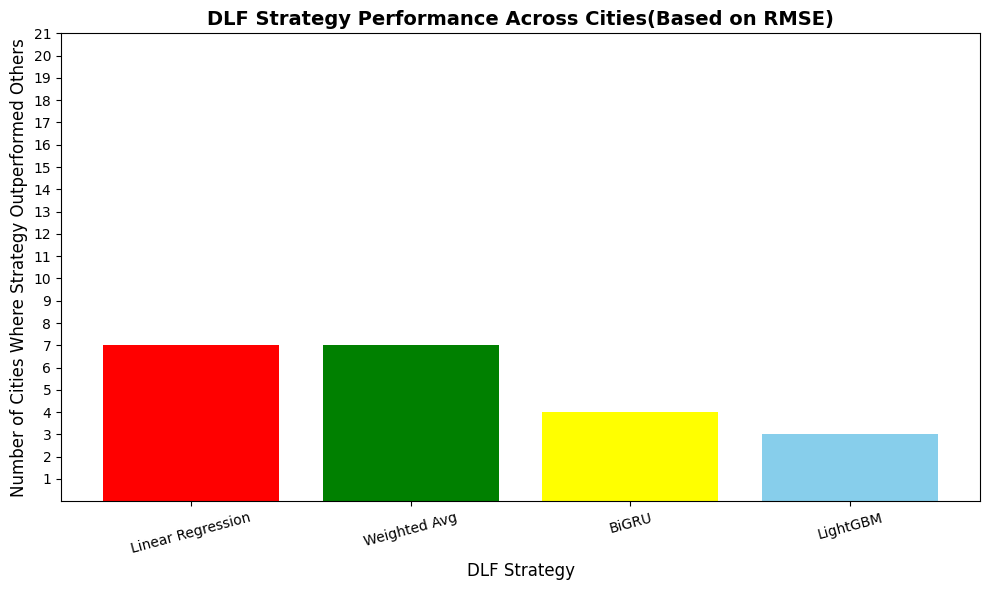

In [46]:
plt.figure(figsize=(10, 6))
plt.bar(strategy_count.index, strategy_count.values, color=['red','green','yellow','skyblue'])
plt.title('DLF Strategy Performance Across Cities(Based on RMSE)', fontsize=14, fontweight='bold')
plt.xlabel('DLF Strategy', fontsize=12)
plt.ylabel('Number of Cities Where Strategy Outperformed Others', fontsize=12)
plt.xticks(rotation=15)
plt.yticks(np.arange(1,22,1))
plt.tight_layout()
plt.show()

# **Choosing Strategy Based on RMSE because it penalises more for large errors**

In [ ]:
'''
patrol_divisons = {1: 'Central',
 2: 'Rampart',
 3: 'Southwest',
 4: 'Hollenbeck',
 5: 'Harbor',
 6: 'Hollywood',
 7: 'Wilshire',
 8: 'West LA',
 9: 'Van Nuys',
 10: 'West Valley',
 11: 'Northeast',
 12: '77th Street',
 13: 'Newton',
 14: 'Pacific',
 15: 'N Hollywood',
 16: 'Foothill',
 17: 'Devonshire',
 18: 'Southeast',
 19: 'Mission',
 20: 'Olympic',
 21: 'Topanga'}'''

"\npatrol_divisons = {1: 'Central',\n 2: 'Rampart',\n 3: 'Southwest',\n 4: 'Hollenbeck',\n 5: 'Harbor',\n 6: 'Hollywood',\n 7: 'Wilshire',\n 8: 'West LA',\n 9: 'Van Nuys',\n 10: 'West Valley',\n 11: 'Northeast',\n 12: '77th Street',\n 13: 'Newton',\n 14: 'Pacific',\n 15: 'N Hollywood',\n 16: 'Foothill',\n 17: 'Devonshire',\n 18: 'Southeast',\n 19: 'Mission',\n 20: 'Olympic',\n 21: 'Topanga'}"